# Chapter 4: Implementing a GPT model from scratch To Generate Text

## 4.1 Coding an LLM architecture

- We will code the architecture of the smallest GPT-2 model (124 million parameters), as outlined in Radford et al.'s [Language Models are Unsupervised Multitask Learners](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf) (note that the initial report lists it as 117M parameters, but this was later corrected in the model weight repository)

- Configuration details for the 124 million parameter GPT-2 model include:

In [1]:
GPT_CONFIG_124M = {
    "vocab_size": 50_257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

In [6]:
from typing import Any
import torch
import torch.nn as nn


class DummyGPTModel(nn.Module):
    def __init__(self, cfg: dict[str, Any]) -> None:
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Use a placeholder for TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        # Use a placeholder for LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx: torch.Tensor) -> torch.Tensor:
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg: dict[str, Any]) -> None:
        super().__init__()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape: int, eps: float = 1e-5) -> None:
        super().__init__()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x

In [7]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [8]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)

logits = model(batch)
print(f"Output shape: {logits.shape}")
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


## 4.2 Normalising activations with layer normalisation

- Layer normalisation, also know as LayerNorm ([Be et al. 2016](https://arxiv.org/abs/1607.06450)), centers the activations of the neural network layer around mean 0 and normalises their varience to 1
- This stabilises training and enables faster convergence to effective weights
- Layer normalisation is applied both before and after multi-head attention module within the transformer block, which we will implement later, it's also applied before the final output layer

- Let's see how LayerNorm works by passing a small inpit sample through a simple neural network layer:

In [9]:
torch.manual_seed(123)

batch_example = torch.randn(2, 5)

layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


- Let's compute the mean and variance for each of the 2 inputs above:

In [14]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)

print(f"Mean:\n{mean}")
print(f"Variance:\n{var}")

Mean:
tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


- Subracting the mean and dividing by the squere-root of the variance (standard deviation) centers the inputs to have a mean of 0 and a variance of 1 across the column (feature) dimension:

In [15]:
out_norm = (out - mean) / torch.sqrt(var)
print(f"Normalised layer outputs:\n{out_norm}")

mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print(f"Mean:\n{mean}")
print(f"Variance:\n{var}")

Normalised layer outputs:
tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
tensor([[-5.9605e-08],
        [ 1.9868e-08]], grad_fn=<MeanBackward1>)
Variance:
tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


- Each input is centered at 0 and has a unit variance of 1; to improve readability, we can disable PyTorch's scientific notation:

In [16]:
torch.set_printoptions(sci_mode=False)
print(f"Mean:\n{mean}")
print(f"Variance:\n{var}")

Mean:
tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
Variance:
tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


- Above, we normalised tje features of each input
- Now, using the same idea, we can implement a `LayerNorm` class:

In [17]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim: int) -> None:
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

**Scale and shift**
- Note that in addition to performing the normalisation by subtracting the mean and dividing by the variance, we added two trainable parameters, `scale` and `shift` parameter
- The initial `scale` (multiplying by 1) and `shift` (adding 0) values don't have any effect; however, `scale` and `shift` are trainable parameters that the LLM automatically adjusts during training if it is determined that doing so would improve the model's performance on its training task
- This allows the model to learn appropriate scaling and shifting that best suit the data it is processing
- Note that we also add a smaller value (`eps`) before computing the square root of the variance; this is to avoid division-by-zero errors if the variance is 0

**Biased variance**
- In the variance calculation above, setting `unbiased=False` means using the formula $\sum{(x_i-\bar{x})^2}/n$ to compute the variance where n is the sample size (here, the number of features or columns); this formula does not include Bessel's correction (which uses `n-1` in the denominator), thus providing a biased estimate of the variance
- For LLMs, where the embedding dimension `n` is very large, the difference between using `n` and `n-1` is negligible
- However, GPT-2 was trained with a biased variance in the normalisation layers, which is why we also adpoted this setting for compatibility reasons with the pretrained wights that we will load in later chapters
- Let's now try out `LayerNom` in practice:

In [18]:
ln = LayerNorm(emb_dim=6)
out_ln = ln(out)

In [19]:
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, keepdim=True, unbiased=False)

print(f"Mean:\n{mean}")
print(f"Variance:\n{var}")

Mean:
tensor([[-0.0000],
        [-0.0000]], grad_fn=<MeanBackward1>)
Variance:
tensor([[0.9995],
        [0.9997]], grad_fn=<VarBackward0>)


- Variance is not exactly 1 because we use `eps`

## 4.3 Implementing a feed forward network with GELU activations

- We will implement a small neural network submodule that is used as part of the transformer block in LLMs
- We start with activation function
- In DL, ReLU (Rectified Linear Unit) activation function are commonly used due to their simplicity and effectiveness in various nerual network architectures
- In LLMs, various other types of activation functions are used beyond the traditional ReLU; two notable examples are GELU (Gaussian Error Linear Unit) and SwiGLU (Swish-Gated Linear Unit)
GELU and SwiGLU are more complex, smooth activation functions incorporating Gaussian and sigmoid-gated linear units, respectively, offering better performance for deep learning models, unlike the simpler, piecewise linear function of ReLU

- GELU ([Hendrycks and Gimpel 2016]()) can be implemented in several ways; the exact version is defined as $GELU(x) = x \cdot \Phi{(x)}$, where $\Phi{(x)}$ is the cumulative distribution function of the standard Gaussian distribution.
- In practice, it's common to implement a computationally cheaaper approximation: $GELU(x) \approx 0.5 \cdot x \cdot (1 + \tanh{[\sqrt{2/\pi} \cdot (x + 0.044715 \cdot x^3)]})$ (the original GPT-2 model was trained with this approximation)

In [23]:
class GELU(nn.Module):
    def __init__(self) -> None:
        super().__init__()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return (
            0.5
            * x
            * (
                1
                + torch.tanh(
                    torch.sqrt(torch.tensor(2 / torch.pi))
                    * (x + 0.044715 * torch.pow(x, 3))
                )
            )
        )

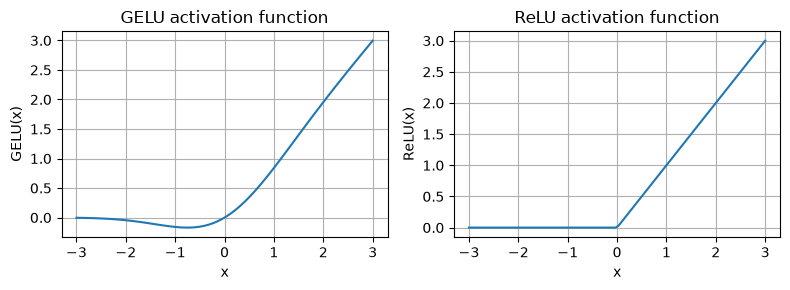

In [24]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

- As we can see, ReLU is a piecewise linear function that outputs the input directly if it is positive; otherwise, it outputs zero
- GELU is a smooth, non-linear function that approximates ReLU but with a non-zero gradient for negative values (except at approximately -0.75)
Next, let's implement the small neural network module, `FeedForward`, that we will be using in the LLM's transfomer block later:

In [25]:
class FeedForward(nn.Module):
    def __init__(self, cfg: dict[str, Any]) -> None:
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layers(x)

In [26]:
print(GPT_CONFIG_124M["emb_dim"])

768


In [27]:
ffn = FeedForward(GPT_CONFIG_124M)

x = torch.rand(2, 3, 768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


## 4.4 Adding shortcut connections

- Shortcut connections are also called skip or residual connections
- Originally, shortcut connections were proposed in deep networks from computer vision (residual networks) to mitigate vanishing gradient problems
- A shortcut connection creates an alternative shorter path for the gradient to flow through the network
- This is achieve by adding the output of one layer to the output of a later layer, usually skipping one or more layers in between

In [33]:
class ExampleDeepNearualNetwork(nn.Module):
    def __init__(self, layer_sizes: list[int], use_shortcut: bool) -> None:
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList(
            [
                nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
                nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
                nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
                nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
                nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU()),
            ]
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for layer in self.layers:
            layer_output = layer(x)
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output

        return x


def print_gradients(model: nn.Module, x: torch.Tensor) -> None:
    output = model(x)
    target = torch.tensor([[0.0]])

    loss = nn.MSELoss()
    loss = loss(output, target)

    loss.backward()

    for name, param in model.named_parameters():
        if "weight" in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

- Let's print the gradient value first **without** shortcut connections:

In [35]:
layer_sizes = [3, 3, 3, 3, 3, 1]

sample_input = torch.tensor([[1.0, 0.0, -1.0]])

torch.manual_seed(123)
model_without_shortcut = ExampleDeepNearualNetwork(layer_sizes, use_shortcut=False)
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152041071094573
layers.3.0.weight has gradient mean of 0.0013988735154271126
layers.4.0.weight has gradient mean of 0.005049645435065031


- Nex, let's print the gradient values **with** shortcut connections:

In [36]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNearualNetwork(layer_sizes, use_shortcut=True)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694106817245483
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258540630340576


- As we can see based on the output above, shortcut connections prevent the gradient from vanishing in the early layers (towards `layer.0`)
- We will use this concept of a shortcut connection next when we implment a transformer block

## 4.5 Connecting attention and linear layers in a transformer block

- 